## Cell Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import os

sns.set_theme(style="whitegrid")
os.makedirs("../reports/feature_engineering_plots", exist_ok=True)

## Loading cleaned data

In [2]:
df = pd.read_csv("../data/processed/cleaned.csv")
print(df.shape)
print(df.dtypes)

(1500, 9)
job_title                  str
experience_level           str
years_of_experience      int64
education_required         str
annual_salary_usd      float64
country                    str
remote_work                str
company_size               str
industry                   str
dtype: object


## Checking salary skewness
It is around 0.72.So, We will apply a log transform to annual_salary_usd to bring the distribution closer to normal, which helps linear regression. 

Salary skewness: 0.7211


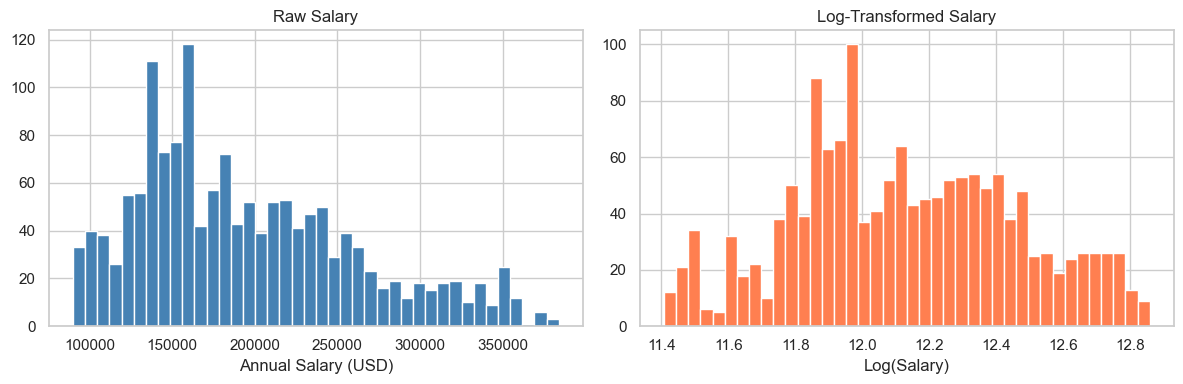

In [3]:
print("Salary skewness:", df["annual_salary_usd"].skew().round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["annual_salary_usd"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Raw Salary")
axes[0].set_xlabel("Annual Salary (USD)")

axes[1].hist(np.log(df["annual_salary_usd"]), bins=40, color="coral", edgecolor="white")
axes[1].set_title("Log-Transformed Salary")
axes[1].set_xlabel("Log(Salary)")

plt.tight_layout()
plt.savefig("../reports/feature_engineering_plots/salary_skew_check.png", dpi=150)
plt.show()

## Applying Log Transform

In [4]:
df["log_salary"] = np.log(df["annual_salary_usd"])
print("Log salary skewness:", df["log_salary"].skew().round(4))

Log salary skewness: 0.0918


## Ordinal encoding

In [5]:
experience_map = {
    "Entry (0-2 yrs)": 1,
    "Mid (3-5 yrs)": 2,
    "Senior (6-9 yrs)": 3,
    "Lead (10+ yrs)": 4
}

education_map = {
    "Bootcamp/Self-taught": 1,
    "Associate's": 2,
    "Bachelor's": 3,
    "Master's": 4,
    "PhD": 5
}

company_size_map = {
    "Startup (1-50)": 1,
    "SME (51-500)": 2,
    "Mid-size (501-5000)": 3,
    "Enterprise (5000+)": 4,
    "Big Tech (FAANG+)": 5
}

df["experience_encoded"] = df["experience_level"].map(experience_map)
df["education_encoded"] = df["education_required"].map(education_map)
df["company_size_encoded"] = df["company_size"].map(company_size_map)

print(df[["experience_level","experience_encoded",
          "education_required","education_encoded",
          "company_size","company_size_encoded"]].head(8))

   experience_level  experience_encoded    education_required  \
0  Senior (6-9 yrs)                   3              Master's   
1  Senior (6-9 yrs)                   3            Bachelor's   
2  Senior (6-9 yrs)                   3           Associate's   
3  Senior (6-9 yrs)                   3            Bachelor's   
4    Lead (10+ yrs)                   4  Bootcamp/Self-taught   
5   Entry (0-2 yrs)                   1  Bootcamp/Self-taught   
6     Mid (3-5 yrs)                   2              Master's   
7     Mid (3-5 yrs)                   2              Master's   

   education_encoded         company_size  company_size_encoded  
0                  4       Startup (1-50)                     1  
1                  3   Enterprise (5000+)                     4  
2                  2    Big Tech (FAANG+)                     5  
3                  3         SME (51-500)                     2  
4                  1   Enterprise (5000+)                     4  
5                 

## Visualizing ordinal encoded features vs log salary

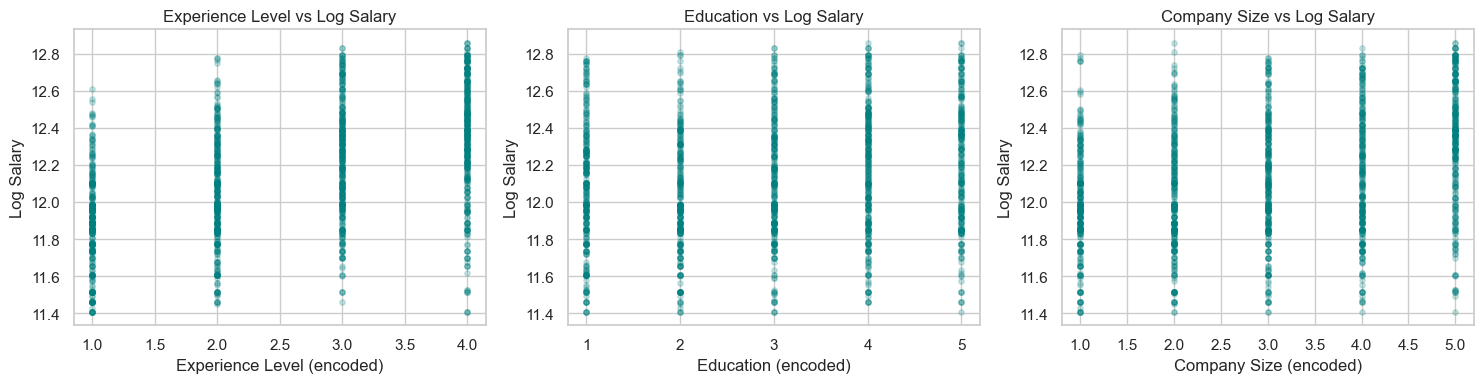

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label in zip(axes,
    ["experience_encoded", "education_encoded", "company_size_encoded"],
    ["Experience Level", "Education", "Company Size"]):
    ax.scatter(df[col], df["log_salary"], alpha=0.2, color="teal", s=15)
    ax.set_xlabel(label + " (encoded)")
    ax.set_ylabel("Log Salary")
    ax.set_title(f"{label} vs Log Salary")

plt.tight_layout()
plt.savefig("../reports/feature_engineering_plots/ordinal_vs_log_salary.png", dpi=150)
plt.show()

## One Hot Encoding

In [10]:
ohe_cols = ["job_title", "country", "remote_work", "industry"]

df_encoded = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

# Newer pandas returns bool dtype for OHE columns — convert to int
bool_cols = df_encoded.select_dtypes(include="bool").columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Shape after OHE:", df_encoded.shape)
print("Bool columns converted to int:", len(bool_cols))

Shape after OHE: (1500, 59)
Bool columns converted to int: 50


## Dropping Original string columns and raw salary

In [11]:
cols_to_drop = [
    "experience_level", "education_required", "company_size",
    "annual_salary_usd"
]

df_encoded.drop(columns=cols_to_drop, inplace=True)

print("Final shape:", df_encoded.shape)
print(df_encoded.columns.tolist())

Final shape: (1500, 55)
['years_of_experience', 'log_salary', 'experience_encoded', 'education_encoded', 'company_size_encoded', 'job_title_AI Business Analyst', 'job_title_AI Compliance Manager', 'job_title_AI Engineer', 'job_title_AI Ethics Officer', 'job_title_AI Infrastructure Eng', 'job_title_AI Product Manager', 'job_title_AI Research Scientist', 'job_title_AI Security Engineer', 'job_title_AI Solutions Architect', 'job_title_Computer Vision Engineer', 'job_title_Data Engineer (AI)', 'job_title_Data Scientist', 'job_title_Deep Learning Engineer', 'job_title_Generative AI Engineer', 'job_title_LLM Engineer', 'job_title_ML Engineer', 'job_title_MLOps Engineer', 'job_title_Multimodal AI Engineer', 'job_title_NLP Engineer', 'job_title_Prompt Engineer', 'job_title_RAG Engineer', 'job_title_Robotics Engineer (AI)', 'job_title_Senior Data Scientist', 'job_title_Senior ML Engineer', 'country_Canada', 'country_China', 'country_France', 'country_Germany', 'country_Global', 'country_India',

In [12]:
non_numeric = df_encoded.select_dtypes(exclude="number").columns.tolist()
print("Non-numeric columns remaining:", non_numeric)

Non-numeric columns remaining: []


## Scaling Numeric Values

In [13]:
features_to_scale = ["years_of_experience", "experience_encoded", "education_encoded", "company_size_encoded"]

scaler = StandardScaler()
df_encoded[features_to_scale] = scaler.fit_transform(df_encoded[features_to_scale])

print(df_encoded[features_to_scale].describe().round(3))

       years_of_experience  experience_encoded  education_encoded  \
count             1500.000            1500.000           1500.000   
mean                -0.000              -0.000             -0.000   
std                  1.000               1.000              1.000   
min                 -1.950              -1.325             -1.427   
25%                 -0.829              -1.325             -0.710   
50%                 -0.081              -0.438              0.007   
75%                  0.667               1.336              0.723   
max                  3.285               1.336              1.440   

       company_size_encoded  
count              1500.000  
mean                 -0.000  
std                   1.000  
min                  -1.429  
25%                  -0.717  
50%                  -0.005  
75%                   0.707  
max                   1.418  


## Correlation of all features with log salary

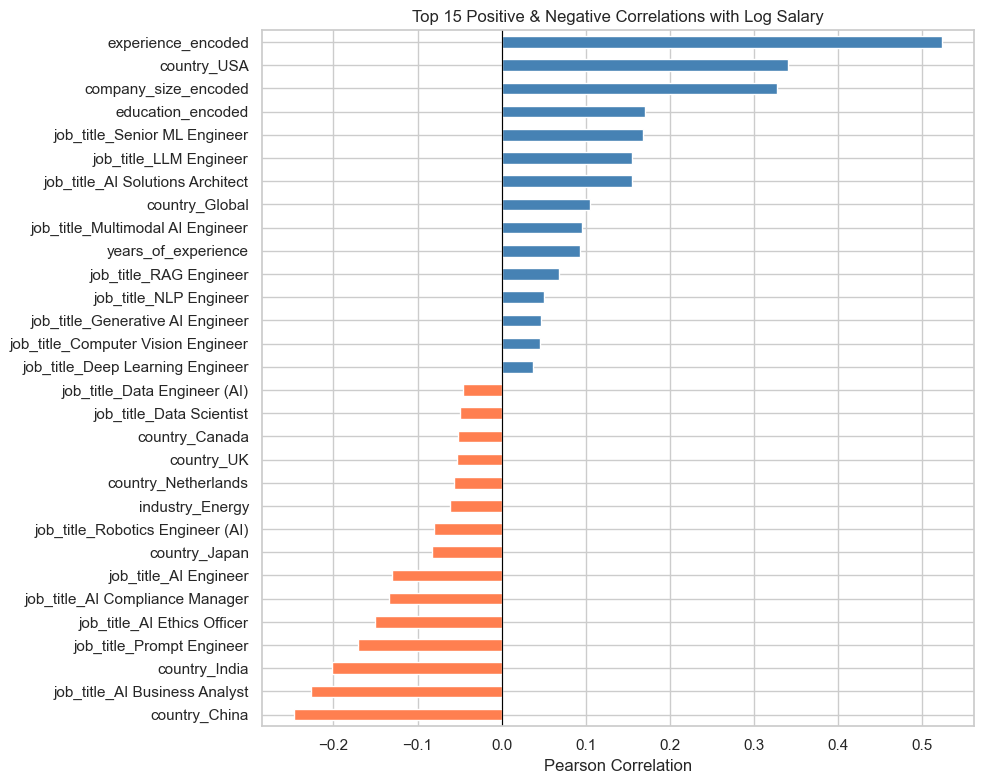

In [14]:
correlations = df_encoded.corr()["log_salary"].drop("log_salary").sort_values(ascending=False)

top_pos = correlations.head(15)
top_neg = correlations.tail(15)
top_features = pd.concat([top_pos, top_neg])

plt.figure(figsize=(10, 8))
top_features.sort_values().plot(kind="barh", color=["coral" if x < 0 else "steelblue" for x in top_features.sort_values()])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 15 Positive & Negative Correlations with Log Salary")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.savefig("../reports/feature_engineering_plots/feature_correlations.png", dpi=150)
plt.show()

## Checking

In [15]:
print(df_encoded.isnull().sum()[df_encoded.isnull().sum() > 0])

Series([], dtype: int64)


## Saving Model Ready Dataset

In [16]:
df_encoded.to_csv("../data/processed/model_ready.csv", index=False)
print("Saved model_ready.csv")
print("Shape:", df_encoded.shape)
print("Target column: log_salary")

Saved model_ready.csv
Shape: (1500, 55)
Target column: log_salary


# Feature Engineering Summary — AI Job Market Salary Prediction

## 1. Log Transformation of Target Variable

The raw salary skewness was **0.72**, placing it in the moderate right-skew range.
A log transform was applied to create a new target column `log_salary`.

| Statistic | Raw Salary | Log Salary |
|-----------|-----------|------------|
| Mean | $194,892 | 12.124 |
| Std Dev | $66,507 | 0.335 |
| Min | $90,000 | 11.408 |
| Max | $384,000 | 12.858 |
| Skewness | 0.7211 | **0.0918** |

The log transform reduced skewness from 0.72 to 0.09 — essentially symmetric.
This is the target column used in all modelling. Predictions from the model are
converted back to dollars using `np.exp()`.

---

## 2. Ordinal Encoding

Three categorical columns carry a natural rank order and were encoded as integers
rather than one-hot encoded, to preserve that ordering.

| Column | Encoding |
|--------|----------|
| `experience_level` | Entry=1, Mid=2, Senior=3, Lead=4 |
| `education_required` | Bootcamp=1, Associate's=2, Bachelor's=3, Master's=4, PhD=5 |
| `company_size` | Startup=1, SME=2, Mid-size=3, Enterprise=4, Big Tech=5 |

### Correlation with log salary after encoding

| Feature | Pearson Correlation |
|---------|-------------------|
| experience_encoded | **0.5229** |
| company_size_encoded | **0.3275** |
| education_encoded | 0.1706 |
| years_of_experience | 0.0933 |

`experience_encoded` is the single strongest numeric predictor at 0.52. `company_size_encoded`
follows at 0.33. `education_encoded` shows moderate signal at 0.17.
`years_of_experience` remains weak at 0.09 even after the log transform — confirming
that the categorical experience level captures seniority far better than raw years.

---

## 3. Ordinal Features vs Log Salary (Scatter Plots — Image 1)

### Experience Level
Mean log salary rises cleanly from **11.89 (Entry)** to **12.34 (Lead)** — a 0.45
log-unit gap, which corresponds to roughly a **57% salary increase** in dollar terms.
Each encoded step shows a visible upward shift in the scatter, confirming a strong
monotonic relationship. This is the best-behaved ordinal feature in the dataset.

### Education
The trend is weaker and less clean. Mean log salary by level:

| Encoded | Level | Mean Log Salary |
|---------|-------|----------------|
| 1 | Bootcamp/Self-taught | 12.082 |
| 2 | Associate's | 12.033 |
| 3 | Bachelor's | 12.114 |
| 4 | Master's | 12.178 |
| 5 | PhD | 12.215 |

Bootcamp (1) outperforms Associate's (2) and nearly matches Bachelor's (3), which
breaks the expected ordinal pattern. This is a known limitation of ordinal encoding
for education in tech datasets — skill demonstration outweighs credentials at the
lower end. The scatter plot shows heavy vertical overlap across all five levels,
indicating education alone explains little salary variance.

### Company Size
A consistent upward trend from Startup to Big Tech:

| Encoded | Level | Mean Log Salary |
|---------|-------|----------------|
| 1 | Startup | 11.994 |
| 2 | SME | 12.036 |
| 3 | Mid-size | 12.115 |
| 4 | Enterprise | 12.144 |
| 5 | Big Tech | 12.329 |

Big Tech sits noticeably above the rest, with a 0.19 log-unit gap over Enterprise —
approximately a **21% salary premium**. The step from Startup to Enterprise is gradual;
the jump to Big Tech is abrupt. The scatter shows similar vertical spread at each level,
meaning company size shifts the salary distribution upward without narrowing variance.

---

## 4. One-Hot Encoding

Four nominal columns with no natural order were one-hot encoded using `pd.get_dummies`
with `drop_first=True` to avoid multicollinearity.

| Column | Unique Values | Columns Generated (drop_first) |
|--------|--------------|-------------------------------|
| `job_title` | 25 | 24 |
| `country` | 14 | 13 |
| `remote_work` | 3 | 2 |
| `industry` | 12 | 11 |

**Note:** pandas 2.0+ returns boolean dtype from `get_dummies`. All bool columns were
explicitly cast to int (`astype(int)`) before any further processing.

---

## 5. Feature Correlation Chart (Image 2)

### Top positive correlations with log salary

| Feature | Correlation |
|---------|------------|
| experience_encoded | +0.523 |
| country_USA | +0.341 |
| company_size_encoded | +0.328 |
| education_encoded | +0.171 |
| job_title_Senior ML Engineer | +0.168 |
| job_title_LLM Engineer | +0.155 |
| job_title_AI Solutions Architect | +0.155 |
| country_Global | +0.105 |
| job_title_Multimodal AI Engineer | +0.096 |
| years_of_experience | +0.093 |

Experience, USA location, and company size are the three dominant drivers — all with
correlations above 0.32. Specific high-value job titles (LLM Engineer, AI Solutions
Architect, Senior ML Engineer) also contribute meaningfully at around 0.15–0.17.

### Top negative correlations with log salary

| Feature | Correlation |
|---------|------------|
| country_China | -0.246 |
| job_title_AI Business Analyst | -0.227 |
| country_India | -0.202 |
| job_title_Prompt Engineer | -0.171 |
| job_title_AI Ethics Officer | -0.151 |
| job_title_AI Compliance Manager | -0.134 |
| job_title_AI Engineer | -0.131 |
| country_Japan | -0.083 |
| job_title_Robotics Engineer (AI) | -0.080 |
| industry_Energy | -0.061 |

China and India locations are the strongest negative predictors, consistent with
real-world USD-adjusted market rates. Non-technical or governance roles (AI Business
Analyst, AI Ethics Officer, AI Compliance Manager, Prompt Engineer) cluster at the
negative end, confirming the pattern observed in EDA.

---

## 6. Column Cleanup

After encoding, the original string columns and raw salary were dropped:

- Dropped: `experience_level`, `education_required`, `company_size`, `annual_salary_usd`
- Retained: `log_salary` as the model target

---

## 7. Feature Scaling

Four continuous/ordinal numeric columns were scaled using `StandardScaler` before
being passed to the model.

| Feature | Mean (pre-scale) | Std (pre-scale) | Range |
|---------|-----------------|----------------|-------|
| years_of_experience | 6.22 | 2.68 | 1–15 |
| experience_encoded | 2.49 | 1.13 | 1–4 |
| education_encoded | 2.99 | 1.40 | 1–5 |
| company_size_encoded | 3.01 | 1.41 | 1–5 |

After scaling, all four have mean ≈ 0 and std ≈ 1. OHE columns (already 0/1) were
not scaled.

---

## 8. Final Model-Ready Dataset

| Property | Value |
|----------|-------|
| Rows | 1,500 |
| Total columns | 55 |
| Feature columns | 54 |
| Target column | `log_salary` |
| Null values | 0 |
| Non-numeric columns | 0 |

Saved to `data/processed/model_ready.csv`. Notebook 3 loads this file directly
and proceeds to train/test split and modelling.